## Part f Classification

In [17]:
from pathlib import Path
import sys


here = Path.cwd()
candidates = [here] + list(here.parents)
for p in candidates:
    if (p / "Code").is_dir():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Couldn't find a 'Code' folder in this project.")


import autograd.numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
import argparse
import random
import itertools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from Code.ffnn2 import NeuralNetwork as FFNN 
from Code.scheduler import Adam, RMS_prop, Constant, Scheduler
from Code.activations import sigmoid, identity, derivate, RELU, LRELU
from Code.architectures import build_architectures, build_architectures_class, build_architectures_2, build_architectures_from_list
from Code.comparison import run_classification_comparison
from Code.cost import CostCrossEntropy, dCostCrossEntropy, softmax


sns.set_theme(style="white", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 200
plt.rcParams.update({
    "savefig.dpi": 200,
    "savefig.bbox": "tight"
})


In [18]:
"""Data loading and preprocessing"""

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Features: float32 in [0,1]
X = mnist.data.astype(np.float32) / 255.0

# Labels: keep as integers (OpenML may give strings -> cast to int64)
y = mnist.target.astype(np.int64)

# Train/test split (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Ensure dtypes (features float32; labels int64)
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.int64).ravel()
y_test  = y_test.astype(np.int64).ravel()

# One-hot encode labels (indices must be integers)
n_classes = int(np.max(y_train)) + 1  # for MNIST this is 10
Y_train = np.eye(n_classes, dtype=np.float32)[y_train]
Y_test  = np.eye(n_classes, dtype=np.float32)[y_test]



In [19]:

#drop GD and SGD for speed
optimizers_stage1 = {
    "rms_prop": (RMS_prop, {"rho": 0.9}),
    "adam":     (Adam,     {"rho": 0.9, "rho2": 0.999}),
}

# drop sigmoid for speed 
activations_stage1 = {
    "relu": RELU,
    "lrelu": LRELU,
}

N = 10
depths = (0, 1, 2, 3)
widths = (64, 128, 256)
input_nodes = X_train.shape[1]

architectures_to_sweep = build_architectures_from_list(
    hidden_layer_lists=[(32,), (64,), (64, 128), (128, 256), (32, 64, 64)],
    out_dim=10,
    include_zero=True
)

#architectures_to_sweep = build_architectures_2(depths=depths, widths=widths, out_dim=N)

## Helper function

In [20]:
def run_classification(
    optimizer_class, layer_output_sizes, hidden_activation_func,
    X_train, Y_train, X_test, Y_test,
    eta, lam, epochs=10, batches=64, **opt_kwargs
):
    # 1. Define Activation Functions for all layers
    n_hidden_layers = len(layer_output_sizes) - 1
    # Hidden layers use the chosen function; Output layer MUST use softmax for multiclass CE [2, 6]
    activation_funcs = [hidden_activation_func] * n_hidden_layers + [softmax]
    activation_ders = [derivate(f) for f in activation_funcs]

    nn = FFNN(
        network_input_size=input_nodes,
                    layer_output_sizes=tuple(layer_output_sizes),
                    activation_funcs=activation_funcs,
                    activation_ders=activation_ders,
                    cost_fun=CostCrossEntropy,
                    cost_der=dCostCrossEntropy,
                    seed=42
    )
    nn.reset_weights()

    # 3. Instantiate Scheduler (e.g., Adam, RMSprop, Constant)
    scheduler_instance = optimizer_class(eta=eta, **opt_kwargs)

    # 4. Train the network (using L2 regularization 'lam')
    nn.fit(
        X=X_train,
        t=Y_train, # Expects one-hot encoded targets [14]
        scheduler=scheduler_instance,
        epochs=epochs,
        batches=batches,
        lam=lam # L2 regularization [15]
    )

    # 5. Evaluate Performance (Accuracy is the metric for classification [16])
    # The FFNN predict method typically returns probabilities (after Softmax)
    test_probs = nn.predict(X_test)
    y_hat = np.argmax(test_probs, axis=1) # Get predicted labels (0-9) [17]
    
    # Convert true one-hot labels back to integer labels for comparison
    y_true_labels = np.argmax(Y_test, axis=1) 
    
    accuracy = np.mean(y_hat == y_true_labels) # Equivalent to accuracy_score [16]
    
    return accuracy

In [34]:


def train_eval_ffnn_classification(
    arch_name,
    opt_name,
    act_name,
    eta,
    l1,
    l2,
    epochs,
    batch_size,
):
    layer_sizes = architectures_to_sweep[arch_name]
    hidden_func = activations_stage1[act_name]
    opt_class, fixed_params = optimizers_stage1[opt_name]

    # hidden activations + softmax output
    n_hidden = len(layer_sizes) - 1
    activation_funcs = [hidden_func] * n_hidden + [softmax]
    activation_ders  = [derivate(f) for f in activation_funcs]

    nn = FFNN(
        network_input_size=X_train.shape[1],
        layer_output_sizes=tuple(layer_sizes),
        activation_funcs=activation_funcs,
        activation_ders=activation_ders,
        cost_fun=CostCrossEntropy,
        cost_der=dCostCrossEntropy,
        seed=42,
    )
    nn.reset_weights()

    opt_kwargs = dict(fixed_params)
    opt_kwargs["eta"] = float(eta)
    scheduler = opt_class(**opt_kwargs)

    batches = batch_size

    nn.fit(
        X_train,
        Y_train,
        scheduler=scheduler,
        batches=batches,
        epochs=epochs,
        l1=float(l1),
        l2=float(l2),
    )

    # evaluate on test set
    probs = nn.predict(X_test)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_test).mean()

    return float(acc)


def train_eval_ffnn_classification_with_preds(
    arch_name,
    opt_name,
    act_name,
    eta,
    l1,
    l2,
    epochs,
    batch_size,
):
    layer_sizes = architectures_to_sweep[arch_name]
    hidden_func = activations_stage1[act_name]
    opt_class, fixed_params = optimizers_stage1[opt_name]

    n_hidden = len(layer_sizes) - 1
    activation_funcs = [hidden_func] * n_hidden + [softmax]
    activation_ders  = [derivate(f) for f in activation_funcs]

    nn = FFNN(
        network_input_size=X_train.shape[1],
        layer_output_sizes=tuple(layer_sizes),
        activation_funcs=activation_funcs,
        activation_ders=activation_ders,
        cost_fun=CostCrossEntropy,
        cost_der=dCostCrossEntropy,
        seed=42,
    )
    nn.reset_weights()

    opt_kwargs = dict(fixed_params)
    opt_kwargs["eta"] = float(eta)
    scheduler = opt_class(**opt_kwargs)

    nn.fit(
        X_train,
        Y_train,
        scheduler=scheduler,
        batches=batch_size,
        epochs=epochs,
        l1=float(l1),
        l2=float(l2),
    )

    probs = nn.predict(X_test)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_test).mean()

    return float(acc), y_pred, probs



## Multi-stage tuning

Stage one - optimizer and learning rate sweep over different architectures

In [22]:
eta_vals = np.logspace(-5, -1, 5) #logspace for speed 
lambda_vals = [0.0] #iterate over L1 and L2 later
epochs_sweep = 5 # Keep epochs low initially to speed up the sweep
batch_size = 256

all_combinations = list(itertools.product(
    architectures_to_sweep.items(),          # Architecture (name, layer_sizes)
    optimizers_stage1.items(),             # Optimizer (name, (class, params))
    activations_stage1.items(),     # Activation (name, func)
    eta_vals,
    lambda_vals
))
print(f"Total combos: {len(all_combinations)}")

#set a maximum number of combinations to run
N_max_combos = 250
if len(all_combinations) > N_max_combos:
    random.seed(42)
    search_combos = random.sample(all_combinations, k=N_max_combos)
    print(f"Running randomized search on {N_max_combos} samples.")
else:
    search_combos = all_combinations

Total combos: 120


In [23]:
results = []
for combo in search_combos:
    (arch_name, layer_sizes), (opt_name, (opt_class, fixed_params)), \
    (act_name, act_func), eta, lam = combo
    
    # Consolidate kwargs for the optimizer/scheduler
    opt_kwargs = {'eta': eta} 
    opt_kwargs.update(fixed_params)

    # Run the model
    try:
        accuracy = run_classification(
            opt_class, layer_sizes, act_func,
            X_train, Y_train, X_test, Y_test,
            epochs=epochs_sweep, batches=batch_size,
            # Explicitly pass regularization term to the NN training
            lam=lam, 
            **opt_kwargs
        )

        results.append({
            'architecture': arch_name,
            'optimizer': opt_name,
            'activation': act_name,
            'eta': eta,
            'lambda': lam,
            'accuracy': accuracy
        })
        print(f"Running {arch_name}/{opt_name}/{act_name} (eta={eta:.1e}): Accuracy={accuracy:.4f}")
        
    except Exception as e:
        # Handle failures (e.g., exploding gradients) gracefully
        print(f"Skipped {arch_name}/{opt_name}. Error: {e}")
        results.append({
            'architecture': arch_name,
            'optimizer': opt_name,
            'activation': act_name,
            'eta': eta,
            'lambda': lam,
            'accuracy': np.nan 
        })


Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-05): Accuracy=0.7274
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-04): Accuracy=0.8669
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-03): Accuracy=0.9154
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-02): Accuracy=0.9181
Running 0_Hidden_Layers/rms_prop/relu (eta=1.0e-01): Accuracy=0.8895
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-05): Accuracy=0.7274
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-04): Accuracy=0.8669
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-03): Accuracy=0.9154
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-02): Accuracy=0.9181
Running 0_Hidden_Layers/rms_prop/lrelu (eta=1.0e-01): Accuracy=0.8895
Running 0_Hidden_Layers/adam/relu (eta=1.0e-05): Accuracy=0.6675
Running 0_Hidden_Layers/adam/relu (eta=1.0e-04): Accuracy=0.8348
Running 0_Hidden_Layers/adam/relu (eta=1.0e-03): Accuracy=0.9059
Running 0_Hidden_Layers/adam/relu (eta=1.0e-02): Accuracy=0.9216
Running 0_Hidden_Layers/adam/relu (eta=1.0e-0

## Find best for each architecture

In [24]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results)

# Drop failed runs
df = df.dropna(subset=["accuracy"])


k = 1

top_k_per_arch = (
    df.sort_values(["architecture", "accuracy"], ascending=[True, False])
      .groupby("architecture", as_index=False)
      .head(k)
      .reset_index(drop=True)
)

print("Top-k configurations per architecture (by accuracy):")
print(top_k_per_arch)


best_per_arch = (
    df.sort_values(["architecture", "accuracy"], ascending=[True, False])
      .groupby("architecture", as_index=False)
      .head(1)
      .reset_index(drop=True)
)

print("Best configuration per architecture (by accuracy):")
print(best_per_arch)




Top-k configurations per architecture (by accuracy):
                   architecture optimizer activation   eta  lambda  accuracy
0               0_Hidden_Layers      adam       relu  0.01     0.0  0.921619
1           1_Hidden_Layer (32)      adam      lrelu  0.01     0.0  0.961000
2           1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3    2_Hidden_Layers (128, 256)      adam      lrelu  0.01     0.0  0.969857
4     2_Hidden_Layers (64, 128)  rms_prop       relu  0.01     0.0  0.969476
5  3_Hidden_Layers (32, 64, 64)  rms_prop      lrelu  0.01     0.0  0.961190
Best configuration per architecture (by accuracy):
                   architecture optimizer activation   eta  lambda  accuracy
0               0_Hidden_Layers      adam       relu  0.01     0.0  0.921619
1           1_Hidden_Layer (32)      adam      lrelu  0.01     0.0  0.961000
2           1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3    2_Hidden_Layers (128, 256)      adam      lr

## Find best overall

In [25]:
stage_a_df = (
    pd.DataFrame(results)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nstage A best (eta refine, lam=0):")
print(stage_a_df.head(10))



stage A best (eta refine, lam=0):
                 architecture optimizer activation   eta  lambda  accuracy
0  2_Hidden_Layers (128, 256)      adam      lrelu  0.01     0.0  0.969857
1   2_Hidden_Layers (64, 128)  rms_prop       relu  0.01     0.0  0.969476
2         1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3         1_Hidden_Layer (64)  rms_prop      lrelu  0.01     0.0  0.969095
4         1_Hidden_Layer (64)      adam       relu  0.01     0.0  0.969000
5   2_Hidden_Layers (64, 128)  rms_prop      lrelu  0.01     0.0  0.968762
6  2_Hidden_Layers (128, 256)      adam       relu  0.01     0.0  0.968143
7         1_Hidden_Layer (64)  rms_prop       relu  0.01     0.0  0.967762
8   2_Hidden_Layers (64, 128)      adam       relu  0.01     0.0  0.967619
9   2_Hidden_Layers (64, 128)      adam      lrelu  0.01     0.0  0.967476


Some notes about the results using epochs=5, batch_size= 256, eta: np.logspace(-5, -1, 5), architecture: depths = (1, 2), widths = (64, 128):

η = 1e-5: hopeless.

η = 1e-4: ok-ish.

η = 1e-3: strong.

η = 1e-2: consistently best (~0.968–0.974).

η = 1e-1: unstable / trash for many configs.

We drop η = 1e-5 and η = 1e-1 moving forward, and focus more on the middle values. 

New eta= [1e-2, 3e-3] and epochs = 50 for stage 2. We take the k best runs and continue. 


In [26]:
df_results = pd.DataFrame(results)

# Find the best overall configuration
best_result = df_results.loc[df_results['accuracy'].idxmax()]
print("\n--- Best Configuration Found ---")
print(best_result)


pivot_table = df_results[
    (df_results['architecture'] == '2L-128N') & 
    (df_results['optimizer'] == 'Adam') & 
    (df_results['activation'] == 'ReLU')
].pivot_table(index='eta', columns='lambda', values='accuracy')


--- Best Configuration Found ---
architecture    2_Hidden_Layers (128, 256)
optimizer                             adam
activation                           lrelu
eta                                   0.01
lambda                                 0.0
accuracy                          0.969857
Name: 98, dtype: object


In [27]:

k = 10
top_k = (df_results
         .sort_values("accuracy", ascending=False)
         .head(k)
         .reset_index(drop=True))

print("\n--- top k configs (by accuracy) ---")
print(top_k)



--- top k configs (by accuracy) ---
                 architecture optimizer activation   eta  lambda  accuracy
0  2_Hidden_Layers (128, 256)      adam      lrelu  0.01     0.0  0.969857
1   2_Hidden_Layers (64, 128)  rms_prop       relu  0.01     0.0  0.969476
2         1_Hidden_Layer (64)      adam      lrelu  0.01     0.0  0.969143
3         1_Hidden_Layer (64)  rms_prop      lrelu  0.01     0.0  0.969095
4         1_Hidden_Layer (64)      adam       relu  0.01     0.0  0.969000
5   2_Hidden_Layers (64, 128)  rms_prop      lrelu  0.01     0.0  0.968762
6  2_Hidden_Layers (128, 256)      adam       relu  0.01     0.0  0.968143
7         1_Hidden_Layer (64)  rms_prop       relu  0.01     0.0  0.967762
8   2_Hidden_Layers (64, 128)      adam       relu  0.01     0.0  0.967619
9   2_Hidden_Layers (64, 128)      adam      lrelu  0.01     0.0  0.967476



We'll do a refined sweep over the two refined etas, with a little higher epoch number. 

In [38]:
eta_refined = [3e-3, 1e-2]
epochs_refined = 50
batch_size = 256

base_configs = (
    top_k[["architecture", "optimizer", "activation"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"base configs: {len(base_configs)}")

stage_a_rows = []

for _, cfg in base_configs.iterrows():
    arch_name = cfg["architecture"]
    opt_name  = cfg["optimizer"]
    act_name  = cfg["activation"]

    layer_sizes = architectures_to_sweep[arch_name]
    opt_class, fixed_params = optimizers_stage1[opt_name]
    act_func = activations_stage1[act_name]

    for eta in eta_refined:
        opt_kwargs = {"eta": eta}
        opt_kwargs.update(fixed_params)

        try:
            acc = run_classification(
                opt_class,
                layer_sizes,
                act_func,
                X_train, Y_train,
                X_test, Y_test,
                epochs=epochs_refined,
                batches=batch_size,
                lam=0.0,
                **opt_kwargs
            )

            stage_a_rows.append({
                "architecture": arch_name,
                "optimizer": opt_name,
                "activation": act_name,
                "eta": eta,
                "reg_type": "none",
                "lambda": 0.0,
                "accuracy": acc,
            })

            print(f"[A] {arch_name}/{opt_name}/{act_name} "
                  f"(eta={eta:.1e}, lam=0) -> acc={acc:.4f}")

        except Exception as e:
            print(f"[A][skip] {arch_name}/{opt_name}/{act_name} "
                  f"(eta={eta:.1e}) error: {e}")
            stage_a_rows.append({
                "architecture": arch_name,
                "optimizer": opt_name,
                "activation": act_name,
                "eta": eta,
                "reg_type": "none",
                "lambda": 0.0,
                "accuracy": np.nan,
            })

stage_a_df = (
    pd.DataFrame(stage_a_rows)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nstage A best (eta refine, lam=0):")
print(stage_a_df.head(10))


base configs: 10
[A] 2_Hidden_Layers (128, 256)/adam/lrelu (eta=3.0e-03, lam=0) -> acc=0.9801
[A] 2_Hidden_Layers (128, 256)/adam/lrelu (eta=1.0e-02, lam=0) -> acc=0.9747
[A] 2_Hidden_Layers (64, 128)/rms_prop/relu (eta=3.0e-03, lam=0) -> acc=0.9727
[A] 2_Hidden_Layers (64, 128)/rms_prop/relu (eta=1.0e-02, lam=0) -> acc=0.9697
[A] 1_Hidden_Layer (64)/adam/lrelu (eta=3.0e-03, lam=0) -> acc=0.9721
[A] 1_Hidden_Layer (64)/adam/lrelu (eta=1.0e-02, lam=0) -> acc=0.9734
[A] 1_Hidden_Layer (64)/rms_prop/lrelu (eta=3.0e-03, lam=0) -> acc=0.9720
[A] 1_Hidden_Layer (64)/rms_prop/lrelu (eta=1.0e-02, lam=0) -> acc=0.9720
[A] 1_Hidden_Layer (64)/adam/relu (eta=3.0e-03, lam=0) -> acc=0.9717
[A] 1_Hidden_Layer (64)/adam/relu (eta=1.0e-02, lam=0) -> acc=0.9736
[A] 2_Hidden_Layers (64, 128)/rms_prop/lrelu (eta=3.0e-03, lam=0) -> acc=0.9730
[A] 2_Hidden_Layers (64, 128)/rms_prop/lrelu (eta=1.0e-02, lam=0) -> acc=0.9669
[A] 2_Hidden_Layers (128, 256)/adam/relu (eta=3.0e-03, lam=0) -> acc=0.9780
[A] 2_Hid

## Stage two

Sweep over top results with L1 and L2

In [40]:
eta_refined = [3e-3]
lambda_refined = [1e-4, 1e-3]
epochs_refined = 50
batch_size = 256
top_n_reg = 3

best_from_stage_a = (
    stage_a_df
    .sort_values("accuracy", ascending=False)
    .head(top_n_reg)
    .reset_index(drop=True)
)

print("\nTop configs from Stage A (original):")
print(best_from_stage_a)

best_archs = best_from_stage_a["architecture"].unique()
print(f"\nRefining L1/L2 for {len(best_archs)} architectures using Adam + LReLU")

stage_b_rows = []

for arch_name in best_archs:
    try:
        acc_none = train_eval_ffnn_classification(
            arch_name=arch_name,
            opt_name="adam",
            act_name="lrelu",
            eta=eta_refined[0],
            l1=0.0,
            l2=0.0,
            epochs=epochs_refined,
            batch_size=batch_size,
        )

        stage_b_rows.append({
            "architecture": arch_name,
            "optimizer": "adam",
            "activation": "lrelu",
            "eta": eta_refined[0],
            "reg_type": "none",
            "lambda": 0.0,
            "l1": 0.0,
            "l2": 0.0,
            "accuracy": acc_none,
        })

        print(f"[B] {arch_name}/adam/lrelu (none, eta={eta_refined[0]:.1e}) -> acc={acc_none:.4f}")

    except Exception as e:
        print(f"[B][skip none] {arch_name}/adam/lrelu error: {e}")
        stage_b_rows.append({
            "architecture": arch_name,
            "optimizer": "adam",
            "activation": "lrelu",
            "eta": eta_refined[0],
            "reg_type": "none",
            "lambda": 0.0,
            "l1": 0.0,
            "l2": 0.0,
            "accuracy": np.nan,
        })

    for reg_type in ("l1", "l2"):
        for lam in lambda_refined:
            if reg_type == "l1":
                l1, l2 = lam, 0.0
            else:
                l1, l2 = 0.0, lam

            try:
                acc = train_eval_ffnn_classification(
                    arch_name=arch_name,
                    opt_name="adam",
                    act_name="lrelu",
                    eta=eta_refined[0],
                    l1=l1,
                    l2=l2,
                    epochs=epochs_refined,
                    batch_size=batch_size,
                )

                stage_b_rows.append({
                    "architecture": arch_name,
                    "optimizer": "adam",
                    "activation": "lrelu",
                    "eta": eta_refined[0],
                    "reg_type": reg_type,
                    "lambda": lam,
                    "l1": l1,
                    "l2": l2,
                    "accuracy": acc,
                })

                print(
                    f"[B] {arch_name}/adam/lrelu "
                    f"({reg_type}, eta={eta_refined[0]:.1e}, lam={lam:.0e}) -> acc={acc:.4f}"
                )

            except Exception as e:
                print(
                    f"[B][skip] {arch_name}/adam/lrelu "
                    f"({reg_type}, eta={eta_refined[0]:.1e}, lam={lam:.0e}) error: {e}"
                )
                stage_b_rows.append({
                    "architecture": arch_name,
                    "optimizer": "adam",
                    "activation": "lrelu",
                    "eta": eta_refined[0],
                    "reg_type": reg_type,
                    "lambda": lam,
                    "l1": l1,
                    "l2": l2,
                    "accuracy": np.nan,
                })

stage_b_df = (
    pd.DataFrame(stage_b_rows)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nStage B best (Adam + LReLU on top Stage A architectures):")
print(stage_b_df.head(20))



Top configs from Stage A (original):
                 architecture optimizer activation    eta reg_type  lambda  \
0  2_Hidden_Layers (128, 256)      adam      lrelu  0.003     none     0.0   
1  2_Hidden_Layers (128, 256)      adam       relu  0.003     none     0.0   
2  2_Hidden_Layers (128, 256)      adam       relu  0.010     none     0.0   

   accuracy  
0  0.980143  
1  0.978048  
2  0.976286  

Refining L1/L2 for 1 architectures using Adam + LReLU
[B] 2_Hidden_Layers (128, 256)/adam/lrelu (none, eta=3.0e-03) -> acc=0.9801
[B] 2_Hidden_Layers (128, 256)/adam/lrelu (l1, eta=3.0e-03, lam=1e-04) -> acc=0.9684
[B] 2_Hidden_Layers (128, 256)/adam/lrelu (l1, eta=3.0e-03, lam=1e-03) -> acc=0.9745
[B] 2_Hidden_Layers (128, 256)/adam/lrelu (l2, eta=3.0e-03, lam=1e-04) -> acc=0.9788
[B] 2_Hidden_Layers (128, 256)/adam/lrelu (l2, eta=3.0e-03, lam=1e-03) -> acc=0.9796

Stage B best (Adam + LReLU on top Stage A architectures):
                 architecture optimizer activation    eta reg_t

Rank the results: 

In [ ]:
stage_b_ranked = (
    stage_b_df
    .sort_values("accuracy", ascending=False)  
    .reset_index(drop=True)
)

print(stage_b_ranked.head(20))


                  architecture optimizer activation    eta reg_type  lambda  \
0   2_Hidden_Layers (128, 256)      adam      lrelu  0.003       l1  0.0000   
1   2_Hidden_Layers (128, 256)      adam      lrelu  0.003       l1  0.0001   
2   2_Hidden_Layers (128, 256)      adam      lrelu  0.003       l1  0.0010   
3   2_Hidden_Layers (128, 256)      adam      lrelu  0.003       l2  0.0000   
4   2_Hidden_Layers (128, 256)      adam      lrelu  0.003       l2  0.0001   
5   2_Hidden_Layers (128, 256)      adam      lrelu  0.003       l2  0.0010   
6    2_Hidden_Layers (64, 128)      adam      lrelu  0.003       l1  0.0000   
7    2_Hidden_Layers (64, 128)      adam      lrelu  0.003       l1  0.0001   
8    2_Hidden_Layers (64, 128)      adam      lrelu  0.003       l1  0.0010   
9    2_Hidden_Layers (64, 128)      adam      lrelu  0.003       l2  0.0000   
10   2_Hidden_Layers (64, 128)      adam      lrelu  0.003       l2  0.0001   
11   2_Hidden_Layers (64, 128)      adam      lrelu 

We found the winning configuration: 
 
 architecture: 2_Hidden_Layers (128, 256) <br>
 optimizer : Adam<br>
 Activation: lrelu<br>
 eta: 0.003<br>
 reg type: l1<br>
 L1 value: 0.001<br>
 Accuracy: 0.980810<br>

 We retrain from scratch using this configuration: 



In [31]:

best_arch = "2_Hidden_Layers (128, 256)"
best_opt  = "adam"
best_act  = "lrelu"
best_eta  = 3e-3

best_l1 = 1e-3   # from best Stage B (L1)
best_l2 = 0.0

final_epochs = 500     
final_batch  = 256

# Optional but good: fix seed for reproducibility
np.random.seed(42)

final_acc = train_eval_ffnn_classification(
    arch_name=best_arch,
    opt_name=best_opt,
    act_name=best_act,
    eta=best_eta,
    l1=best_l1,
    l2=best_l2,
    epochs=final_epochs,
    batch_size=final_batch,
)

print(f"Final from-scratch run:")
print(f"{best_arch} | {best_opt} | {best_act} | "
      f"eta={best_eta:.1e} | L1={best_l1:.1e}, L2={best_l2:.1e} "
      f"-> accuracy={final_acc:.4f}")


NameError: name 'act_softmax' is not defined

Comparison to scikit learn library: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression baseline (multinomial, reasonably strong)
logreg = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1,
)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"LogisticRegression accuracy: {acc_lr:.4f}")


/Users/beateovland/Documents/Fys-stk4155/FYS-STK4155-Project-2/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression accuracy: 0.9195


## Plots

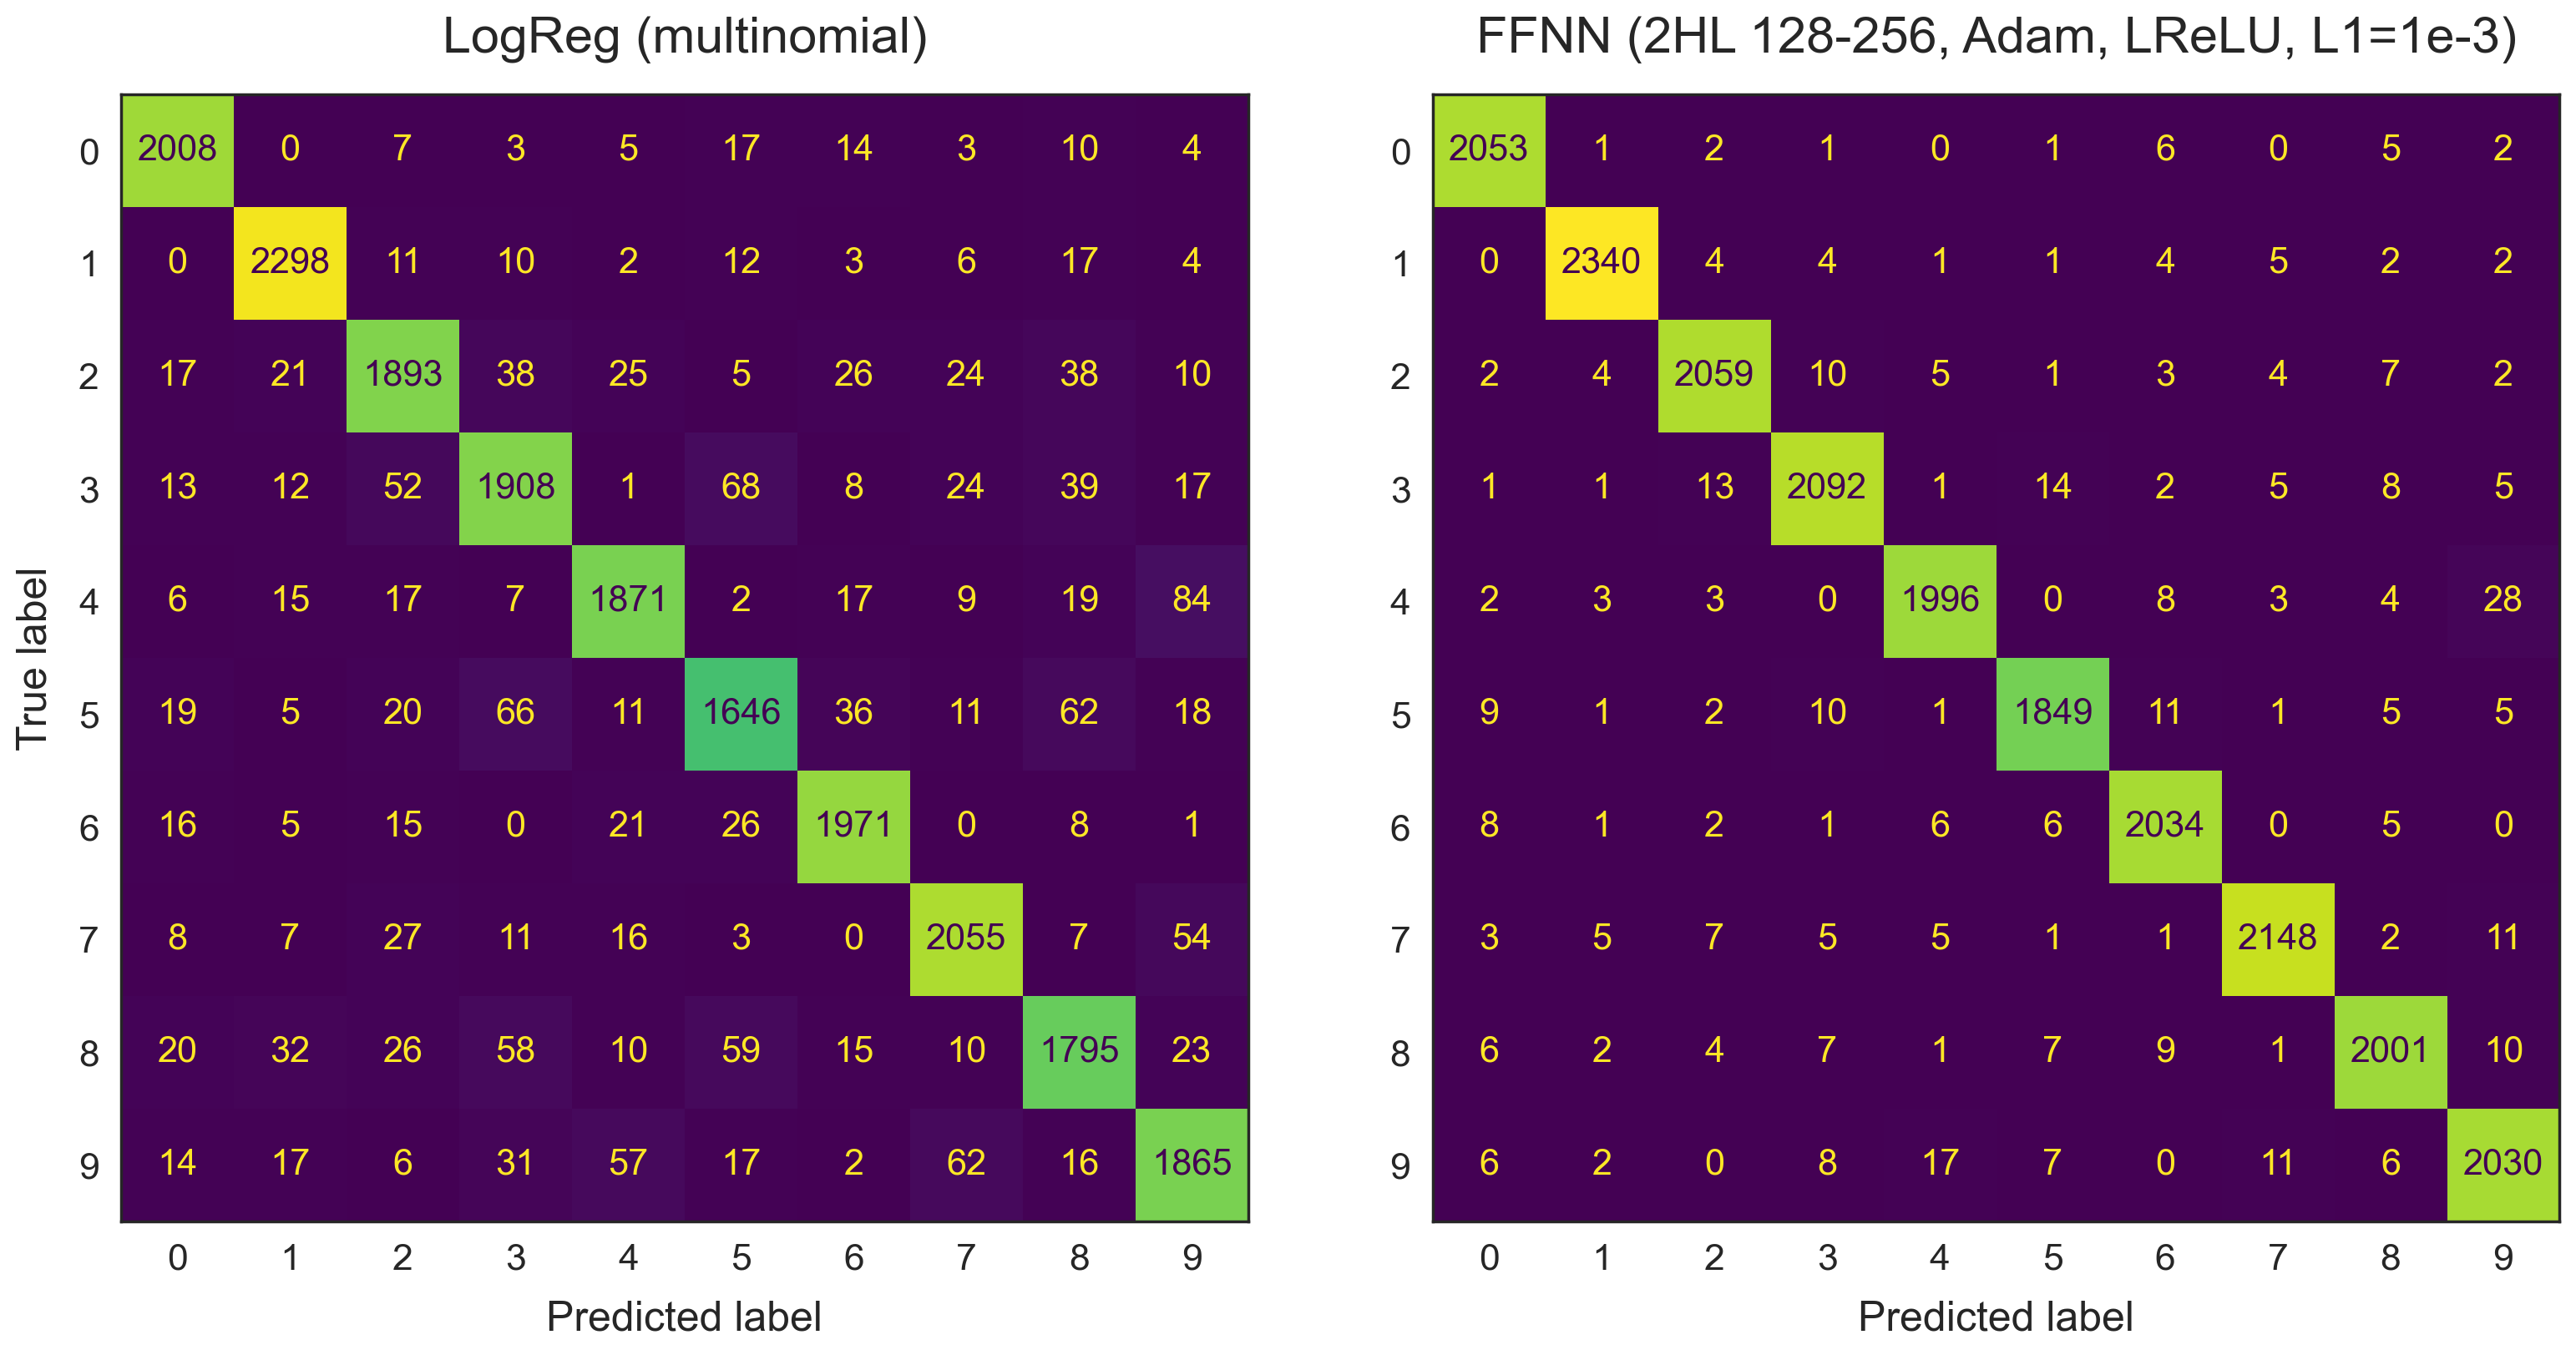

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_epochs = 100

final_acc, y_pred_nn, proba_nn = train_eval_ffnn_classification_with_preds(
    best_arch,
    best_opt,
    best_act,
    best_eta,
    best_l1,
    best_l2,
    final_epochs,
    final_batch,
)

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nn = confusion_matrix(y_test, y_pred_nn)

vmax = max(cm_lr.max(), cm_nn.max())  # shared color scale

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

titles = [
    "LogReg (multinomial)",
    "FFNN (2HL 128-256, Adam, LReLU, L1=1e-3)"
]

for ax, cm, title in zip(axes, (cm_lr, cm_nn), titles):
    disp = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
    disp.plot(
        ax=ax,
        cmap="viridis",              # or any you prefer
        colorbar=False,
        values_format="d",
        im_kw={"vmin": 0, "vmax": vmax},
    )

    ax.set_title(title, fontsize=22, pad=18)
    ax.set_xlabel("Predicted label", fontsize=18, labelpad=10)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(False)

# Only left plot has y-label to avoid clutter
axes[0].set_ylabel("True label", fontsize=18, labelpad=10)
axes[1].set_ylabel("")

plt.show()

